In [1]:


print("Installing required packages...")
print("=" * 60)
!pip install -q mediapipe opencv-python-headless
print("All packages installed successfully!\n")



Installing required packages...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 27.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-api-core 1.34.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<4.0.0dev,>=3.19.5, but you have protobuf 4.25.8 which is incompatible.
google-cloud-bigtable 2.32.0 requires google-api-core[grpc]<3.0.0,>=2.17.0, but you have google-api-core 1.34.1 which is incompatible.
bigframes 2.12.0 requires google-cloud-bigquery[bqstorage,pa

In [2]:

print(" Importing libraries...")
print("=" * 60)
import os
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import pickle
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully!\n")

 Importing libraries...


2025-11-30 18:14:43.219622: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764526483.435125      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764526483.501379      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


All libraries imported successfully!



In [3]:

print("Setting up configuration...")
print("=" * 60)
DATASET_PATH = "/kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train"
print(f"Dataset path: {DATASET_PATH}\n")

Setting up configuration...
Dataset path: /kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train



In [4]:


print("Initializing MediaPipe Hand Detection...")
print("=" * 60)
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5
)
print("MediaPipe initialized successfully!\n")

Initializing MediaPipe Hand Detection...
MediaPipe initialized successfully!



In [5]:

def extract_hand_landmarks(image_path):
    try:
        img = cv2.imread(image_path)
        if img is None: 
            return None
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        results = hands.process(img_rgb)
        
        if results.multi_hand_landmarks:
            hand_landmarks = results.multi_hand_landmarks[0]
            wrist = hand_landmarks.landmark[0]
            flat_landmarks = []
            for landmark in hand_landmarks.landmark:
                flat_landmarks.append(landmark.x - wrist.x)
                flat_landmarks.append(landmark.y - wrist.y)
                flat_landmarks.append(landmark.z - wrist.z)
            return flat_landmarks
        return None
    except:
        return None

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [6]:

print(" Starting feature extraction...")
print("=" * 60)

landmark_data = []
stats = {'total_processed': 0, 'successful': 0, 'failed': 0}

class_folders = sorted([f for f in os.listdir(DATASET_PATH) 
                        if os.path.isdir(os.path.join(DATASET_PATH, f))])

for label_folder in class_folders:
    folder_path = os.path.join(DATASET_PATH, label_folder)
    print(f"\n Processing class: {label_folder}")
    
    try:
        image_files = [f for f in os.listdir(folder_path) 
                      if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        if not image_files:
            print(f"  No images in {label_folder}")
            continue
    except Exception as e:
        print(f"  Error: {e}")
        continue
    
    for image_name in tqdm(image_files, desc=f"  {label_folder}", leave=False):
        image_path = os.path.join(folder_path, image_name)
        stats['total_processed'] += 1
        
        landmarks = extract_hand_landmarks(image_path)
        
        if landmarks is not None:
            landmark_data.append([label_folder] + landmarks)
            stats['successful'] += 1
        else:
            stats['failed'] += 1
    
    print(f"  Processed {len(image_files)} images")


try:
    hands.close()
except:
    pass

print("\n" + "=" * 60)
print(" EXTRACTION COMPLETE!")
print(f" Total: {stats['total_processed']}")
print(f" Success: {stats['successful']}")
print(f"Failed: {stats['failed']}")
print(f" Rate: {(stats['successful']/stats['total_processed']*100):.2f}%\n")


 Starting feature extraction...

 Processing class: A


W0000 00:00:1764526496.500963      75 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1764526496.528554      75 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


  A:   0%|          | 0/3000 [00:00<?, ?it/s]

W0000 00:00:1764526496.634807      72 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


  Processed 3000 images

 Processing class: B


...

  Processed 3000 images

 Processing class: nothing


  nothing:   0%|          | 0/3000 [00:00<?, ?it/s]

  Processed 3000 images

 Processing class: space


  space:   0%|          | 0/3000 [00:00<?, ?it/s]

  Processed 3000 images

 EXTRACTION COMPLETE!
 Total: 87000
 Success: 63676
Failed: 23324
 Rate: 73.19%



In [7]:

print("Creating dataset...")
print("=" * 60)

column_names = ['label']
for i in range(21):
    column_names.extend([f'x{i}', f'y{i}', f'z{i}'])

df = pd.DataFrame(landmark_data, columns=column_names)

print(f" Shape: {df.shape}")
print(f"Classes: {df['label'].nunique()}")

Creating dataset...
 Shape: (63676, 64)
Classes: 29


In [8]:


print("\n Class distribution:")
print("=" * 60)
class_counts = df['label'].value_counts().sort_index()
print(class_counts)




 Class distribution:
label
A          2187
B          2207
C          1988
D          2463
E          2308
F          2876
G          2440
H          2393
I          2384
J          2578
K          2700
L          2527
M          1565
N          1276
O          2265
P          2042
Q          2093
R          2541
S          2551
T          2349
U          2516
V          2548
W          2456
X          2158
Y          2585
Z          2351
del        1701
nothing       3
space      1625
Name: count, dtype: int64


In [9]:

print("\n Saving...")
print("=" * 60)
df.to_pickle("asl_landmarks.pkl")
print(" Saved: asl_landmarks.pkl")




 Saving...
 Saved: asl_landmarks.pkl


In [10]:
###phase 2

In [11]:

print("📦 Installing required packages...")
print("=" * 60)

!pip install -q matplotlib seaborn

print(" All packages installed successfully!\n")


📦 Installing required packages...
 All packages installed successfully!



In [12]:


print("Importing libraries...")
print("=" * 60)

import os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(f" TensorFlow version: {tf.__version__}")
print(f" GPU Available: {tf.config.list_physical_devices('GPU')}")
print(" All libraries imported successfully!\n")


Importing libraries...
 TensorFlow version: 2.18.0
 GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
 All libraries imported successfully!



In [13]:


print(" Loading processed data...")
print("=" * 60)

df = pd.read_pickle("/kaggle/input/signlanguage/asl_landmarks.pkl")
print(f" Loaded!")
print(f" Shape: {df.shape}")
print(f" Classes: {df['label'].nunique()}\n")


 Loading processed data...
 Loaded!
 Shape: (63676, 64)
 Classes: 29



In [14]:


print(" Preparing data...")
print("=" * 60)

X = df.drop('label', axis=1).values
y = df['label'].values

print(f" Features: {X.shape}")
print(f" Labels: {y.shape}")

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)
print(f" Classes: {num_classes}\n")


 Preparing data...
 Features: (63676, 63)
 Labels: (63676,)
 Classes: 29



In [15]:

print(" Splitting data...")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f" Train: {X_train.shape[0]}")
print(f" Test: {X_test.shape[0]}\n")


 Splitting data...
 Train: 50940
 Test: 12736



In [16]:


print(" Scaling features...")
print("=" * 60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Features scaled!\n")


 Scaling features...
 Features scaled!



In [17]:


print(" Building model...")
print("=" * 60)

keras.backend.clear_session()

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(" Model built!")
model.summary()


 Building model...


I0000 00:00:1764529307.989854      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764529307.990529      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


 Model built!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 29)             │         1,885 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,213 (239.11 KB)

 Trainable params: 60,317 (235.61 KB)

 Non-trainable params: 896 (3.50 KB)

In [18]:


print("\n Setting up callbacks...")
print("=" * 60)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_asl_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

callbacks = [early_stopping, reduce_lr, checkpoint]
print(" Callbacks ready!\n")



 Setting up callbacks...
 Callbacks ready!



In [19]:


print(" Training...")
print("=" * 60)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

print("\n Training complete!\n")


 Training...
Epoch 1/100


I0000 00:00:1764529311.708577      95 service.cc:148] XLA service 0x7891dc0020e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764529311.709333      95 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764529311.709353      95 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764529312.120318      95 cuda_dnn.cc:529] Loaded cuDNN version 90300


 66/398 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3224 - loss: 2.6281

I0000 00:00:1764529314.675921      95 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6885 - loss: 1.2285
Epoch 1: val_accuracy improved from -inf to 0.97205, saving model to best_asl_model.h5
398/398 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.6889 - loss: 1.2269 - val_accuracy: 0.9720 - val_loss: 0.1186 - learning_rate: 0.0010
Epoch 2/100
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9600 - loss: 0.1642
Epoch 2: val_accuracy improved from 0.97205 to 0.97959, saving model to best_asl_model.h5
398/398 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9600 - loss: 0.1641 - val_accuracy: 0.9796 - val_loss: 0.0744 - learning_rate: 0.0010
Epoch 3/100
394/398 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9671 - loss: 0.1216
Epoch 3: val_accuracy improved from 0.97959 to 0.98335, saving model to best_asl_model.h5
398/398 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9671 - loss: 0.1215 - val_accuracy: 0.9834 - val_loss: 0.0630 - learning_rate: 0.0010
Epoch 4/100
390/398 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accu

In [20]:


print(" Evaluating...")
print("=" * 60)

model.load_weights('best_asl_model.h5')

y_pred = model.predict(X_test_scaled, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

test_accuracy = accuracy_score(y_test, y_pred_classes)
train_loss, train_accuracy = model.evaluate(X_train_scaled, y_train, verbose=0)
test_loss, _ = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f" Results:")
print(f"  Train Accuracy: {train_accuracy*100:.2f}%")
print(f"  Test Accuracy: {test_accuracy*100:.2f}%")
print(f"  Train Loss: {train_loss:.4f}")
print(f"  Test Loss: {test_loss:.4f}\n")


 Evaluating...
 Results:
  Train Accuracy: 99.76%
  Test Accuracy: 99.55%
  Train Loss: 0.0078
  Test Loss: 0.0212



In [21]:


print(" Classification Report:")
print("=" * 60)
report = classification_report(
    y_test, y_pred_classes,
    target_names=label_encoder.classes_,
    digits=3
)
print(report)


 Classification Report:
              precision    recall  f1-score   support

           A      0.995     0.998     0.997       437
           B      1.000     1.000     1.000       441
           C      0.995     0.997     0.996       398
           D      0.998     0.998     0.998       493
           E      0.998     0.994     0.996       462
           F      0.997     0.998     0.997       575
           G      0.998     0.996     0.997       488
           H      0.998     1.000     0.999       479
           I      0.983     0.987     0.985       477
           J      0.996     0.996     0.996       516
           K      1.000     1.000     1.000       540
           L      1.000     0.996     0.998       505
           M      0.969     0.990     0.979       313
           N      0.992     0.965     0.978       255
           O      0.996     0.993     0.994       453
           P      0.998     0.995     0.996       408
           Q      0.998     0.998     0.998       419
   


 Confusion Matrix...


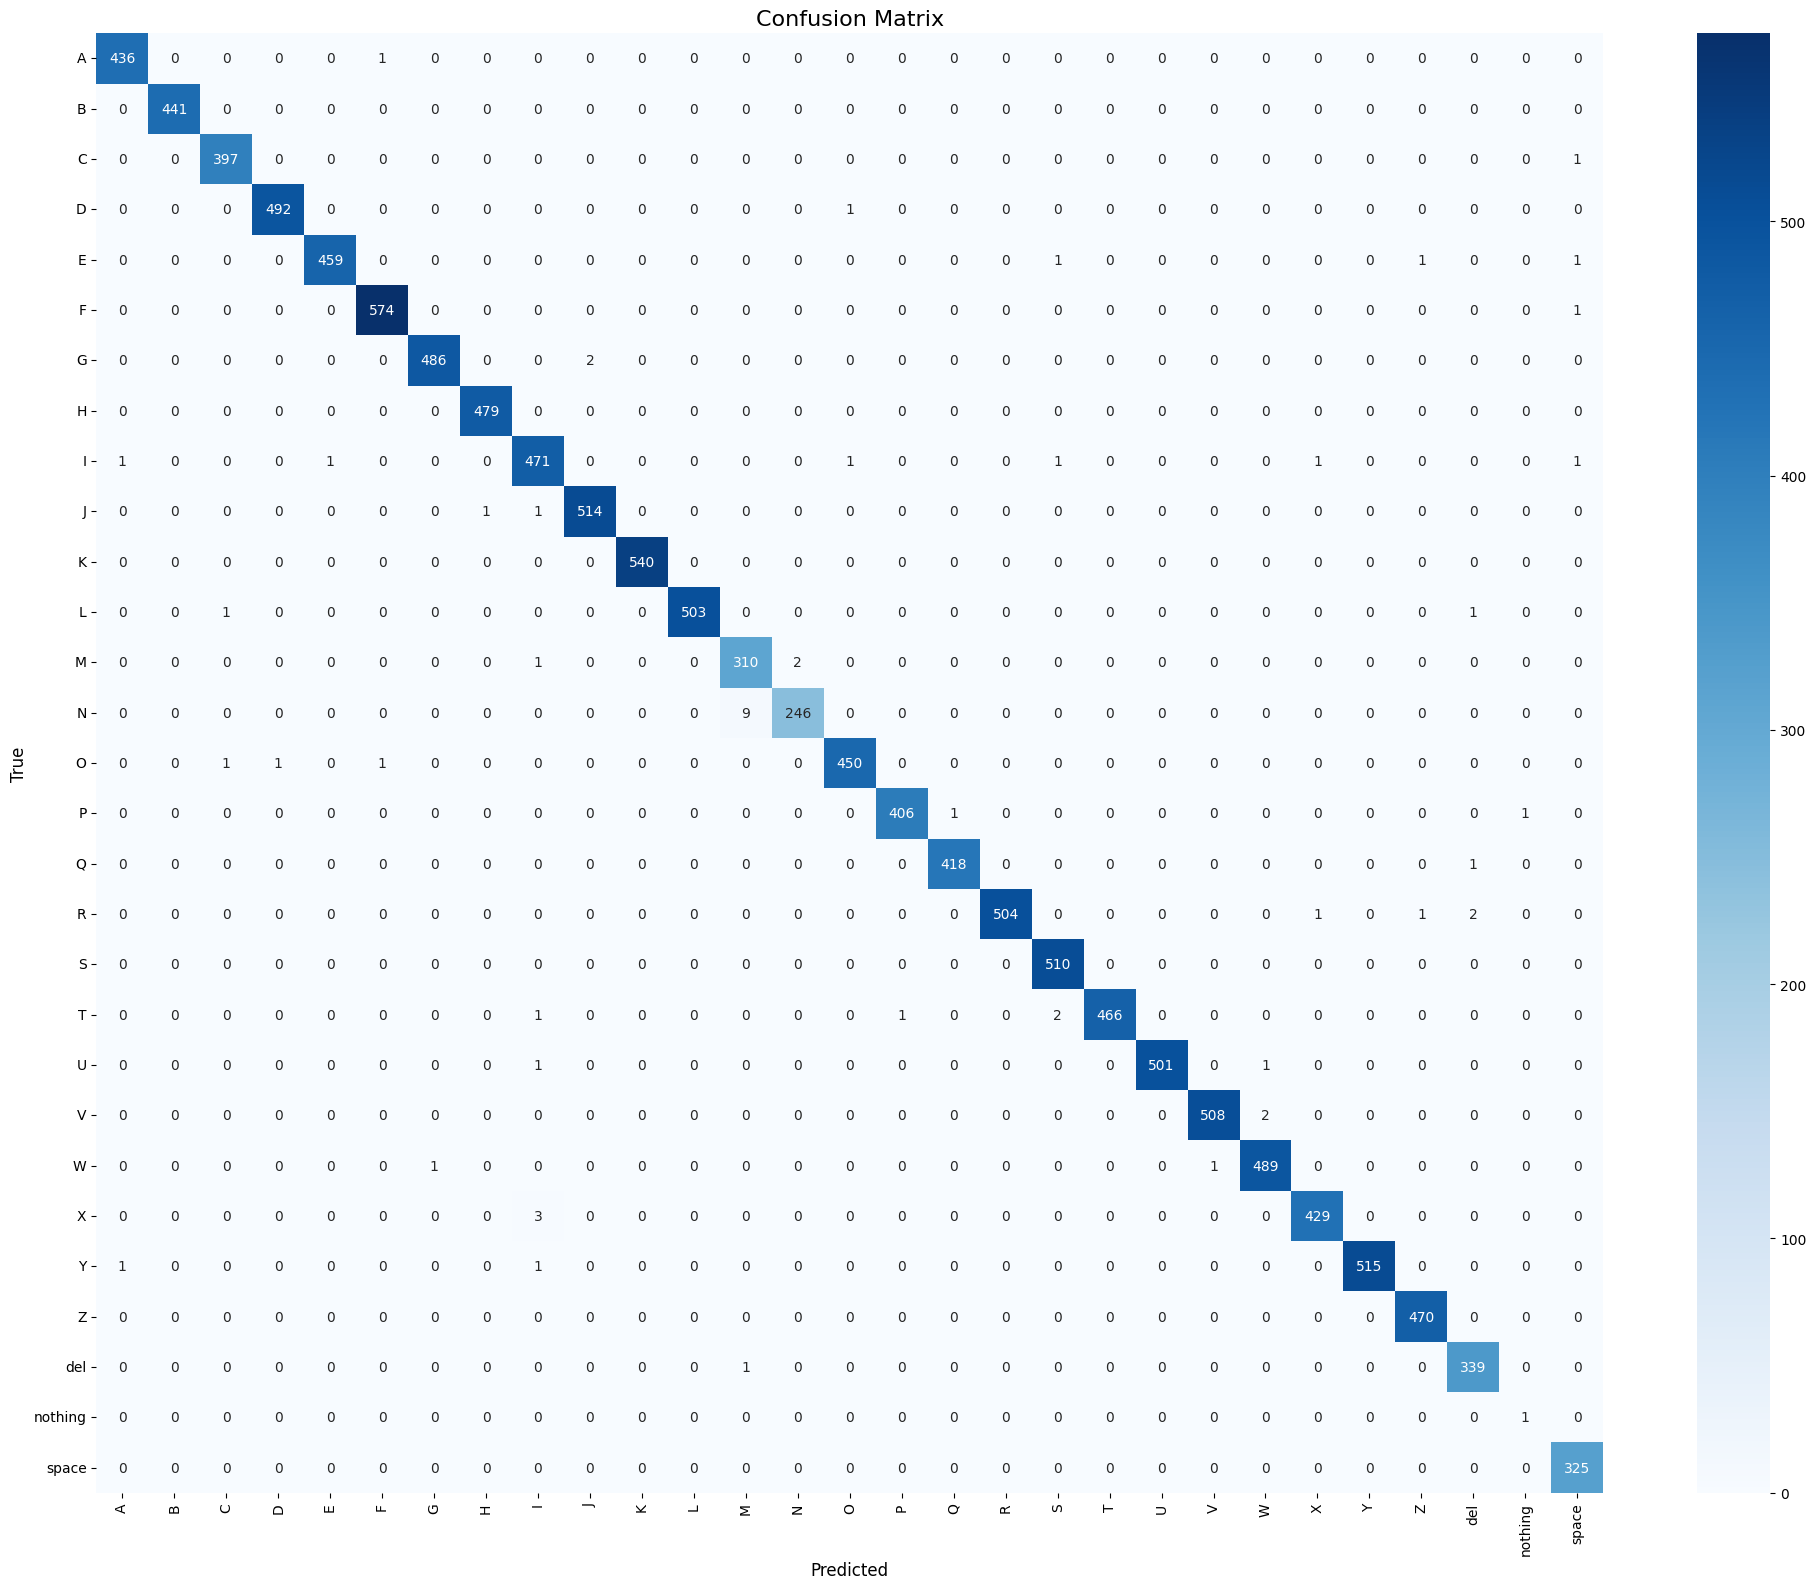

In [22]:


print("\n Confusion Matrix...")
print("=" * 60)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(20, 16))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()



 Training curves...


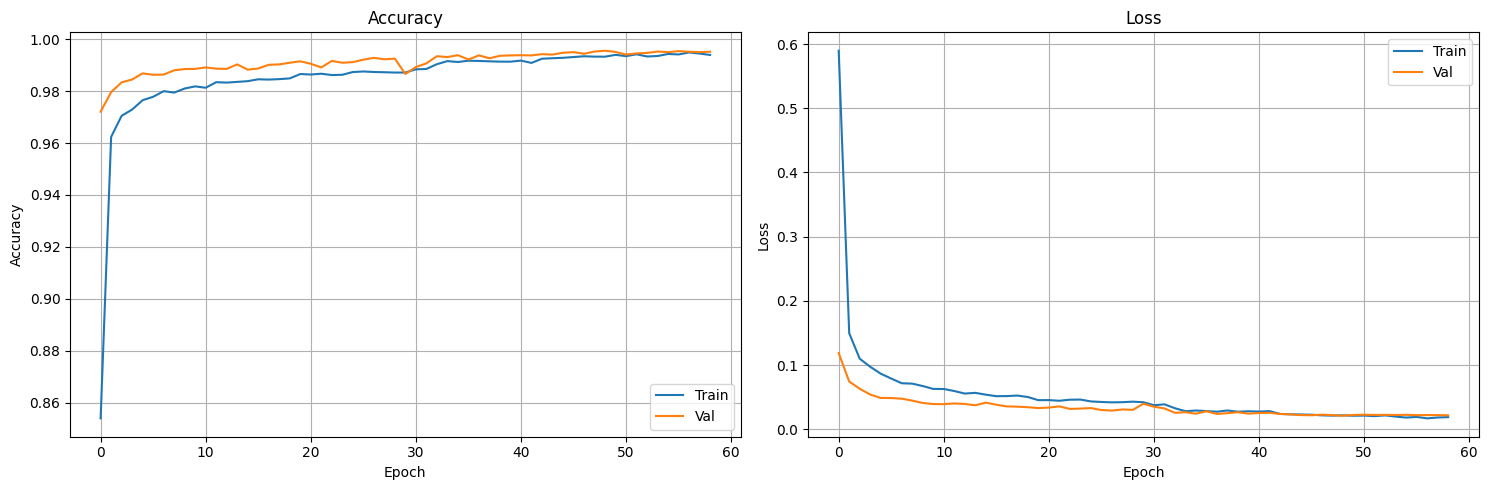

In [23]:


print("\n Training curves...")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()


In [24]:

print("\n Saving files...")
print("=" * 60)

model.save('asl_model.h5')
print(" asl_model.h5")

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print(" label_encoder.pkl")

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(" scaler.pkl")

print("\n" + "=" * 60)

print("=" * 60)
print("\n Download these 3 files:")
print("  • asl_model.h5")
print("  • label_encoder.pkl")
print("  • scaler.pkl")



 Saving files...
 asl_model.h5
 label_encoder.pkl
 scaler.pkl


 Download these 3 files:
  • asl_model.h5
  • label_encoder.pkl
  • scaler.pkl
